#### Analysis of EURO-CORDEX annual mean data (in progress)

- compare data from GCM-RCM combinations of the EURO-CORDEX ensemble (CARMINE selection) over selected time periods to investigate INDICATOR sensitivity to model selection
- Builds a catalog of the available data (currently dummie names model1, model2, ...), scenarios, and time steps
- time period and scenario for comparison can be selected by user
- comparison is done against reference model (1st model given to the list by user)

#### Output of the notebook ####

- Plots include
  * user selected period means for all CSAs in a panel with a joint color scale (relevant for difference plots)
  * user selected period mean differences for all CSAs in a panel with a joint color scale (all given models against reference model)
  * Boxplots for user selcted time period and all selected models (individual time series selection in dedicated boxplot cell)
- Tables include
  * descriptive statistics 
- Output files include
  * panel plots
  * nc-files with period means
  * tables
  * boxplots

#### Important note ####

- Testdata only availabe for CSA "Bologna", notebook is designed to produce all CSA plots to function without modification when data is updated. Empty plot panels might appear

In [1]:
from __future__ import annotations

from pathlib import Path
import sys


# --- find repo root (walk up until .git or outputs/ exists) ---
NOTEBOOK_DIR = Path.cwd()

def find_repo_root(start: Path) -> Path:
    for p in [start] + list(start.parents):
        if (p / ".git").exists():
            return p
    return start

REPO_ROOT = find_repo_root(NOTEBOOK_DIR)

# --- make notebooks/ importable so `notebooks/_lib` can be imported as `_lib` ---
NOTEBOOKS_ROOT = REPO_ROOT / "codes_all_CSAs" / "notebooks"
if str(NOTEBOOKS_ROOT) not in sys.path:
    sys.path.insert(0, str(NOTEBOOKS_ROOT))

# ✅ import paths from _lib (this is the key fix)
from _lib.paths import REPO_ROOT, NOTEBOOKS_ROOT
from _lib.fua_boundaries import load_fua_layer, make_load_fua_boundary, CSA_LIST

# ---- EURO-CORDEX testing paths ----
EUROCORDEX_TESTDATA_ROOT = REPO_ROOT / "2601_EURO_CORDEX_testing_data"
EUROCORDEX_TEST_UNZIP_ROOT = EUROCORDEX_TESTDATA_ROOT / "unzippedIT"
EUROCORDEX_TEST_OUTPUT_ROOT = REPO_ROOT / "outputs" / "eurocordex_testing"

DERIVED_DIR = EUROCORDEX_TEST_OUTPUT_ROOT / "derived"
TABLES_DIR  = EUROCORDEX_TEST_OUTPUT_ROOT / "tables"
PLOTS_DIR   = EUROCORDEX_TEST_OUTPUT_ROOT / "plots"

# FUA boundaries
FUA_DIR = REPO_ROOT / "shapefile" / "UI-boundaries-FUA"

# Create directories (safe: ignored by git)
for d in [EUROCORDEX_TEST_UNZIP_ROOT, EUROCORDEX_TEST_OUTPUT_ROOT, DERIVED_DIR, TABLES_DIR, PLOTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# CSA ↔ FUA name mapping
FUA_MAPPING = {
    "Prague": "Praha",
    "Funen-Odense": "Odense",
    "Athens": "Athina",
    "Birmingham": "West Midlands urban area",
}

_fua_all = load_fua_layer(FUA_DIR)
load_fua_boundary = make_load_fua_boundary(_fua_all, name_field="FUA_NAME", mapping=FUA_MAPPING)

print("REPO_ROOT:", REPO_ROOT)
print("NOTEBOOKS_ROOT:", NOTEBOOKS_ROOT)
print("EUROCORDEX_TESTDATA_ROOT:", EUROCORDEX_TESTDATA_ROOT)
print("EUROCORDEX_TEST_UNZIP_ROOT:", EUROCORDEX_TEST_UNZIP_ROOT)
print("EUROCORDEX_TEST_OUTPUT_ROOT:", EUROCORDEX_TEST_OUTPUT_ROOT)
print("Loaded FUA layer rows:", len(_fua_all))
print("FUA columns:", list(_fua_all.columns))


REPO_ROOT: C:\Users\reinhvlr\OneDrive\CARMINE-T2.4
NOTEBOOKS_ROOT: C:\Users\reinhvlr\OneDrive\CARMINE-T2.4\codes_all_CSAs\notebooks
EUROCORDEX_TESTDATA_ROOT: C:\Users\reinhvlr\OneDrive\CARMINE-T2.4\2601_EURO_CORDEX_testing_data
EUROCORDEX_TEST_UNZIP_ROOT: C:\Users\reinhvlr\OneDrive\CARMINE-T2.4\2601_EURO_CORDEX_testing_data\unzippedIT
EUROCORDEX_TEST_OUTPUT_ROOT: C:\Users\reinhvlr\OneDrive\CARMINE-T2.4\outputs\eurocordex_testing
Loaded FUA layer rows: 672
FUA columns: ['OBJECTID', 'FUA_CODE', 'FUA_NAME', 'COUNTRY_CO', 'Shape_Leng', 'Shape_Area', 'geometry']


In [2]:
import re
import tarfile
import warnings

import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd

In [3]:
archives = sorted([
    p for p in EUROCORDEX_TESTDATA_ROOT.iterdir()
    if p.is_file() and p.name.lower().endswith((".tar.gz", ".tgz"))
])

print("Found archives:", [a.name for a in archives])

for tar_fp in archives:
    stem = tar_fp.name
    stem = stem[:-7] if stem.lower().endswith(".tar.gz") else stem[:-4]  # strip .tar.gz / .tgz
    target = EUROCORDEX_TEST_UNZIP_ROOT / stem
    target.mkdir(parents=True, exist_ok=True)

    if any(target.rglob("*")):
        print("Already extracted:", tar_fp.name, "→", target.name)
        continue

    print("Extracting:", tar_fp.name, "→", target)
    with tarfile.open(tar_fp, mode="r:*") as tf:
        tf.extractall(path=target)

Found archives: ['CORDEX-test.tar.gz']
Already extracted: CORDEX-test.tar.gz → CORDEX-test


In [4]:
# Matches stems like: pr_cordex_model02_rcp85
# (works even if more tokens follow after scenario)
# this cell needs to be adjusted when the file naming changes
FNAME_RE = re.compile(
    r"^(?P<var>[a-z0-9]+)_(?P<dataset>cordex)_(?P<model>model\d+?)_(?P<scenario>[a-z0-9]+)",
    re.IGNORECASE,
)

def parse_cordex_stem(fp: Path) -> dict:
    """
    Parse EURO-CORDEX test filenames like:
      pr_cordex_model02_rcp85(.nc)

    Returns:
      var, dataset, model_id, scenario
    If parsing fails, returns None values.
    """
    stem = fp.stem  # drops .nc
    m = FNAME_RE.match(stem)
    if not m:
        return {"var": None, "dataset": None, "model_id": None, "scenario": None}

    d = m.groupdict()
    return {
        "var": d["var"].lower(),
        "dataset": d["dataset"].lower(),
        "model_id": d["model"].lower(),     # keep model02 as-is
        "scenario": d["scenario"].lower(),  # e.g., rcp85
    }

# quick self-test (edit if you want)
_test = Path("pr_cordex_model02_rcp85.nc")
print("Test parse:", _test.name, "→", parse_cordex_stem(_test))


Test parse: pr_cordex_model02_rcp85.nc → {'var': 'pr', 'dataset': 'cordex', 'model_id': 'model02', 'scenario': 'rcp85'}


In [5]:
# =============================================================================
# 4 — Discover NetCDFs and summarize availability
# =============================================================================

# 1) discover files
nc_files = sorted([
    p for p in EUROCORDEX_TEST_UNZIP_ROOT.rglob("*")
    if p.is_file() and p.suffix.lower() in (".nc", ".nc4", ".cdf")
])

print("UNZIP_ROOT:", EUROCORDEX_TEST_UNZIP_ROOT)
print("Found NetCDFs:", len(nc_files))

if not nc_files:
    warnings.warn("No NetCDF files found. Check extraction and UNZIP_ROOT.")
else:
    print("Example filenames:")
    for p in nc_files[:10]:
        print(" -", p.name)

# 2) parse filename tokens
rows = []
for fp in nc_files:
    meta = parse_cordex_stem(fp)
    rows.append({
        "file_name": fp.name,
        "path": str(fp),
        **meta,
    })

files_df = pd.DataFrame(rows)

# 3) availability summary: what exists?
avail = (
    files_df
    .groupby(["var", "scenario", "model_id"], dropna=False)
    .size()
    .reset_index(name="n_files")
    .sort_values(["var", "scenario", "model_id"])
)

display(avail)

# 4) lists for user selection later
AVAILABLE_VARS = sorted([v for v in files_df["var"].dropna().unique()])
AVAILABLE_SCENARIOS = sorted([s for s in files_df["scenario"].dropna().unique()])
AVAILABLE_MODELS = sorted([m for m in files_df["model_id"].dropna().unique()])

print("AVAILABLE_VARS:", AVAILABLE_VARS)
print("AVAILABLE_SCENARIOS:", AVAILABLE_SCENARIOS)
print("AVAILABLE_MODELS:", AVAILABLE_MODELS)

# 5) quick parse QA (helps catch weird filenames)
n_bad = int(files_df["model_id"].isna().sum())
if n_bad:
    warnings.warn(f"{n_bad} file(s) did not match the expected naming pattern.")
    display(files_df.loc[files_df["model_id"].isna(), ["file_name", "path"]].head(20))


UNZIP_ROOT: C:\Users\reinhvlr\OneDrive\CARMINE-T2.4\2601_EURO_CORDEX_testing_data\unzippedIT
Found NetCDFs: 9
Example filenames:
 - pr_cordex_model01_rcp26.nc
 - pr_cordex_model01_rcp45.nc
 - pr_cordex_model01_rcp85.nc
 - pr_cordex_model02_rcp26.nc
 - pr_cordex_model02_rcp45.nc
 - pr_cordex_model02_rcp85.nc
 - pr_cordex_model03_rcp26.nc
 - pr_cordex_model03_rcp45.nc
 - pr_cordex_model03_rcp85.nc


,var,scenario,model_id,n_files
0,pr,rcp26,model01,1
1,pr,rcp26,model02,1
2,pr,rcp26,model03,1
3,pr,rcp45,model01,1
4,pr,rcp45,model02,1
5,pr,rcp45,model03,1
6,pr,rcp85,model01,1
7,pr,rcp85,model02,1
8,pr,rcp85,model03,1


AVAILABLE_VARS: ['pr']
AVAILABLE_SCENARIOS: ['rcp26', 'rcp45', 'rcp85']
AVAILABLE_MODELS: ['model01', 'model02', 'model03']


In [25]:
import xarray as xr

for fp in files_df["path"].iloc[:3]:
    ds = xr.open_dataset(fp, decode_coords="all")  # fast enough for a few files
    print("\nFILE:", fp.split("\\")[-1])
    for k in [
        "driving_model_id", "model_id", "rcm_name",
        "source_id", "parent_source_id",
        "experiment_id", "institution_id"
    ]:
        if k in ds.attrs:
            print(f"  {k}: {ds.attrs[k]}")
    ds.close()



FILE: pr_cordex_model01_rcp26.nc

FILE: pr_cordex_model01_rcp45.nc

FILE: pr_cordex_model01_rcp85.nc


In [47]:
# =============================================================================
# 5 — USER INPUT (selection for plotting / comparisons)
# =============================================================================

print("AVAILABLE_VARS:", AVAILABLE_VARS)
print("AVAILABLE_SCENARIOS:", AVAILABLE_SCENARIOS)
print("AVAILABLE_MODELS:", AVAILABLE_MODELS)

# --- Core selection ---
VAR_NAME  = AVAILABLE_VARS[0] if AVAILABLE_VARS else "pr"
SCENARIO  = "rcp85" if "rcp85" in AVAILABLE_SCENARIOS else (AVAILABLE_SCENARIOS[0] if AVAILABLE_SCENARIOS else None)

# Select models (order matters: first = reference)
SELECT_MODELS = ["model01", "model02", "model03"]

# Reference-based comparisons: (B - A) = (model - reference)
REF_MODEL = SELECT_MODELS[0]
COMPARE_PAIRS = [(REF_MODEL, m) for m in SELECT_MODELS[1:]]

# --- What derived product to work with ---
# Must match your derived-product naming later (we'll wire this up)
PRODUCT = "period_mean"  

# Only relevant if PRODUCT == "period_mean"
PERIOD_LABEL = "2021-2050"   # set to your actual period labels later

# --- Plot options ---
DO_PANEL_PLOTS = True
PLOT_STAT = "mean"   # options: "mean", "median", "min", "max", "std"
DO_DIFFERENCE_MAPS = True
DO_BOX_PLOTS = True



print("\n--- USER INPUT SUMMARY ---")
print("VAR_NAME:", VAR_NAME)
print("SCENARIO:", SCENARIO)
print("SELECT_MODELS:", SELECT_MODELS)
print("COMPARE_PAIRS (B-A):", COMPARE_PAIRS)
print("PRODUCT:", PRODUCT)
print("PERIOD_LABEL:", PERIOD_LABEL)


AVAILABLE_VARS: ['pr']
AVAILABLE_SCENARIOS: ['rcp26', 'rcp45', 'rcp85']
AVAILABLE_MODELS: ['model01', 'model02', 'model03']

--- USER INPUT SUMMARY ---
VAR_NAME: pr
SCENARIO: rcp85
SELECT_MODELS: ['model01', 'model02', 'model03']
COMPARE_PAIRS (B-A): [('model01', 'model02'), ('model01', 'model03')]
PRODUCT: period_mean
PERIOD_LABEL: 2021-2050


In [48]:
# =============================================================================
# 6 — Select input files based on USER INPUT
# =============================================================================

if SCENARIO is None:
    raise ValueError("SCENARIO is None. Check AVAILABLE_SCENARIOS and user input.")

sel_files_df = files_df[
    (files_df["var"] == VAR_NAME) &
    (files_df["scenario"] == SCENARIO) &
    (files_df["model_id"].isin(SELECT_MODELS))
].copy()

sel_files_df = sel_files_df.sort_values(["model_id", "file_name"]).reset_index(drop=True)

print("Selected files:", len(sel_files_df))
display(sel_files_df[["model_id", "scenario", "var", "file_name", "path"]].head(20))

# sanity: do we have at least one file per selected model?
counts = sel_files_df["model_id"].value_counts().reindex(SELECT_MODELS, fill_value=0)
print("\nFiles per selected model:")
print(counts)

missing_models = [m for m, n in counts.items() if n == 0]
if missing_models:
    warnings.warn(f"No files found for model(s): {missing_models}. Check naming / selection.")


Selected files: 3


,model_id,scenario,var,file_name,path
0,model01,rcp85,pr,pr_cordex_model01_rcp85.nc,C:\Users\reinhvlr\OneDrive\CARMINE-T2.4\2601_E...
1,model02,rcp85,pr,pr_cordex_model02_rcp85.nc,C:\Users\reinhvlr\OneDrive\CARMINE-T2.4\2601_E...
2,model03,rcp85,pr,pr_cordex_model03_rcp85.nc,C:\Users\reinhvlr\OneDrive\CARMINE-T2.4\2601_E...



Files per selected model:
model_id
model01    1
model02    1
model03    1
Name: count, dtype: int64


In [49]:
# =============================================================================
# 7 — Time coverage overview per model (lightweight read)
# =============================================================================

def _time_summary_one(fp: Path) -> dict:
    row = {
        "model_id": parse_cordex_stem(fp)["model_id"],
        "file_name": fp.name,
        "path": str(fp),
        "n_time": None,
        "time_start": None,
        "time_end": None,
    }
    try:
        # use decode_times=True (works for standard and cftime calendars)
        ds = xr.open_dataset(fp, decode_times=True)
        try:
            if "time" in ds.sizes:
                row["n_time"] = int(ds.sizes["time"])
            if "time" in ds.coords and ds.sizes.get("time", 0) > 0:
                row["time_start"] = str(ds["time"].values[0])
                row["time_end"]   = str(ds["time"].values[-1])
        finally:
            ds.close()
    except Exception as e:
        row["time_start"] = f"ERROR: {e}"
    return row

# Build file-level time summary for the selected files
time_rows = []
for p in sel_files_df["path"]:
    time_rows.append(_time_summary_one(Path(p)))

time_df = pd.DataFrame(time_rows)

print("Files summarized:", len(time_df))
display(time_df[["model_id", "n_time", "time_start", "time_end", "file_name"]].head(30))

# Model-level summary
model_time = (
    time_df
    .groupby("model_id", dropna=False)
    .agg(
        n_files=("file_name", "count"),
        min_n_time=("n_time", "min"),
        max_n_time=("n_time", "max"),
        time_start=("time_start", "min"),
        time_end=("time_end", "max"),
    )
    .reset_index()
    .sort_values("model_id")
)

print("\n--- Time coverage per model ---")
display(model_time)

# Optional: store for later use (e.g., in UI / selection validation)
MODEL_TIME_COVERAGE = model_time


Files summarized: 3


,model_id,n_time,time_start,time_end,file_name
0,model01,130,1971-07-02T00:00:00.000000000,2100-07-02T00:00:00.000000000,pr_cordex_model01_rcp85.nc
1,model02,130,1971-07-02T00:00:00.000000000,2100-07-02T00:00:00.000000000,pr_cordex_model02_rcp85.nc
2,model03,130,1971-07-02T00:00:00.000000000,2100-07-02T00:00:00.000000000,pr_cordex_model03_rcp85.nc



--- Time coverage per model ---


,model_id,n_files,min_n_time,max_n_time,time_start,time_end
0,model01,1,130,130,1971-07-02T00:00:00.000000000,2100-07-02T00:00:00.000000000
1,model02,1,130,130,1971-07-02T00:00:00.000000000,2100-07-02T00:00:00.000000000
2,model03,1,130,130,1971-07-02T00:00:00.000000000,2100-07-02T00:00:00.000000000


In [50]:
# =============================================================================
# 8a — Period definitions (annual values already in input!)
# =============================================================================

# Define the periods you want to average over
PERIODS = {
    #"2036-2065": ("2036-01-01", "2065-12-31"),
    # add more later if needed
    "2021-2050": ("2021-01-01", "2050-12-31"),
    #"1981-2010": ("1981-01-01", "2010-12-31"),
}

def subset_period(ds: xr.Dataset, start: str, end: str) -> xr.Dataset:
    """
    Subset by time slice.
    Works for standard datetime + cftime because we slice with strings.
    """
    if "time" not in ds.coords:
        raise KeyError("Dataset has no 'time' coordinate.")
    return ds.sel(time=slice(start, end))

In [51]:
# =============================================================================
# 8b — Derive PERIOD MEANS from annual data (one file)
# =============================================================================

def derive_period_means_for_file(fp: Path) -> list[dict]:
    meta = parse_cordex_stem(fp)
    var = meta["var"]
    if var is None:
        raise ValueError(f"Could not parse variable name from filename: {fp.name}")

    rows = []
    ds = xr.open_dataset(fp, decode_times=True)

    try:
        if var not in ds:
            raise KeyError(f"Variable '{var}' not found in dataset vars: {list(ds.data_vars)}")

        da = ds[var]

        # Compute mean over time for each requested period
        for label, (start, end) in PERIODS.items():
            ds_p = subset_period(ds, start, end)
            if ds_p.sizes.get("time", 0) == 0:
                warnings.warn(f"No timesteps in period {label} for file {fp.name}")
                continue

            da_p = ds_p[var].mean("time")

            out_p = (
                DERIVED_DIR /
                f"{var}_cordex_{meta['model_id']}_{meta['scenario']}_periodmean_{label}.nc"
            )
            da_p.to_netcdf(out_p)

            rows.append({
                "var": var,
                "scenario": meta["scenario"],
                "model_id": meta["model_id"],
                "product": "period_mean",
                "period": label,
                "source_path": str(fp),
                "out_path": str(out_p),
                "n_time_in_period": int(ds_p.sizes.get("time", 0)),
            })

    finally:
        ds.close()

    return rows

In [52]:
# =============================================================================
# 8c — Bulk period-mean derivation + results_df catalog
# =============================================================================

all_results = []

for p in sel_files_df["path"]:
    fp = Path(p)
    print("Period means from:", fp.name)
    all_results.extend(derive_period_means_for_file(fp))

results_df = pd.DataFrame(all_results)

print("Derived products:", len(results_df))
display(results_df.sort_values(["var", "scenario", "model_id", "period"]).reset_index(drop=True))

# Quick sanity check
if results_df.empty:
    warnings.warn("results_df is empty — check PERIODS and whether time slicing matched your data.")
else:
    print("\nCounts by model/period:")
    display(results_df.groupby(["model_id", "period"]).size().reset_index(name="n"))

Period means from: pr_cordex_model01_rcp85.nc
Period means from: pr_cordex_model02_rcp85.nc
Period means from: pr_cordex_model03_rcp85.nc
Derived products: 3


,var,scenario,model_id,product,period,source_path,out_path,n_time_in_period
0,pr,rcp85,model01,period_mean,2021-2050,C:\Users\reinhvlr\OneDrive\CARMINE-T2.4\2601_E...,C:\Users\reinhvlr\OneDrive\CARMINE-T2.4\output...,30
1,pr,rcp85,model02,period_mean,2021-2050,C:\Users\reinhvlr\OneDrive\CARMINE-T2.4\2601_E...,C:\Users\reinhvlr\OneDrive\CARMINE-T2.4\output...,30
2,pr,rcp85,model03,period_mean,2021-2050,C:\Users\reinhvlr\OneDrive\CARMINE-T2.4\2601_E...,C:\Users\reinhvlr\OneDrive\CARMINE-T2.4\output...,30



Counts by model/period:


,model_id,period,n
0,model01,2021-2050,1
1,model02,2021-2050,1
2,model03,2021-2050,1


Using derived file: pr_cordex_model01_rcp85_periodmean_2021-2050.nc
Model: model01
Product/period: period_mean 2021-2050
Color scale: 2.6843085142900234e-05 to 4.918486723909154e-05
Saved panel: C:\Users\reinhvlr\OneDrive\CARMINE-T2.4\outputs\eurocordex_testing\plots\panel\pr_period_mean_2021-2050_panel_model01.png


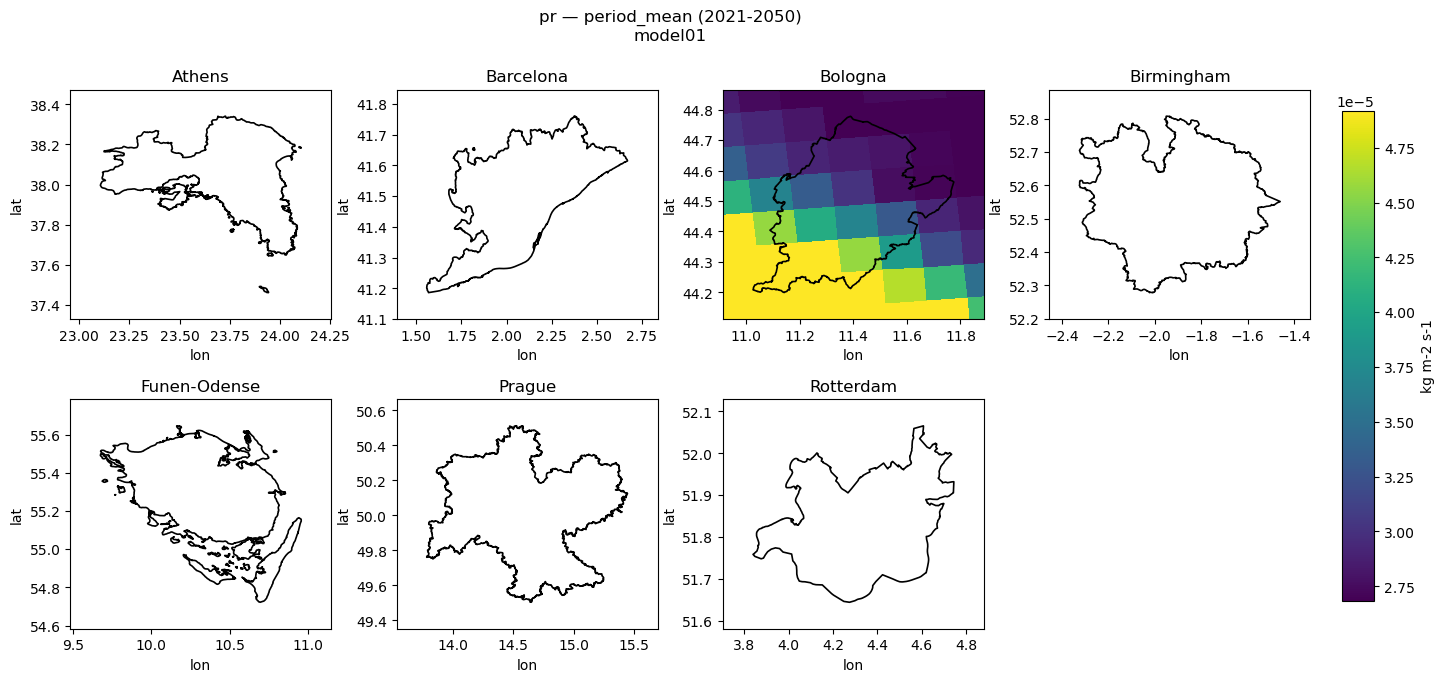

In [53]:
# =============================================================================
# PANEL PLOT — 7 CSAs (FUA zoom), one period_mean + one model (dummy naming)
# =============================================================================
import matplotlib.pyplot as plt
import warnings

# ---- USER CHOICE FOR THE PANEL ----
PANEL_PRODUCT = "period_mean"   # we now store product + period separately
PANEL_PERIOD  = PERIOD_LABEL    # e.g. "1981-2010" (from your USER INPUT cell)
PANEL_MODEL_FILTER = None       # substring to pick one model, e.g. "model02"
CMAP = "viridis"
ROBUST = True
PCTL = (2, 98)
ADD_BOUNDARY = True
DPI = 200

assert "results_df" in globals() and not results_df.empty, "results_df missing (run period mean calculations)."
assert "CSA_LIST" in globals() and len(CSA_LIST) > 0, "CSA_LIST missing."
assert "load_fua_boundary" in globals(), "load_fua_boundary missing (FUA helper not loaded)."

# --- helper: get lon/lat coord names and arrays ---
def get_lon_lat(da: xr.DataArray):
    for lon, lat in [("lon","lat"), ("longitude","latitude"), ("LON","LAT"), ("nav_lon","nav_lat")]:
        if lon in da.coords and lat in da.coords:
            return da[lon].values, da[lat].values
    return None, None

def dissolve_to_lonlat_polygon(csa: str):
    gdf = load_fua_boundary(csa)
    if gdf is None or gdf.empty:
        return None
    bg = gdf
    if getattr(bg, "crs", None) is not None:
        bg = bg.to_crs("EPSG:4326")
    return bg.geometry.union_all()

# --- pick one derived file matching product + period (+ optional model filter) ---
sub = results_df[
    (results_df["product"] == PANEL_PRODUCT) &
    (results_df["period"] == PANEL_PERIOD)
].copy()

if sub.empty:
    raise ValueError(
        f"No derived outputs for product='{PANEL_PRODUCT}' and period='{PANEL_PERIOD}'. "
        f"Available products: {sorted(results_df['product'].unique())}; "
        f"Available periods: {sorted([p for p in results_df['period'].dropna().unique()])}"
    )

if PANEL_MODEL_FILTER is not None:
    sub = sub[sub["model_id"].astype(str).str.contains(PANEL_MODEL_FILTER, case=False, na=False)].copy()
    if sub.empty:
        raise ValueError(f"No derived outputs match PANEL_MODEL_FILTER='{PANEL_MODEL_FILTER}'.")

# choose the first match
picked = sub.iloc[0]
DERIVED_PATH = Path(picked["out_path"])
MODEL_ID = picked.get("model_id")

print("Using derived file:", DERIVED_PATH.name)
print("Model:", MODEL_ID)
print("Product/period:", PANEL_PRODUCT, PANEL_PERIOD)

# --- load map (period_mean has no time/year dim, but keep safeguards) ---
ds = xr.open_dataset(DERIVED_PATH, decode_times=True)
try:
    da = ds[VAR_NAME].squeeze()

    # If some derived product still has year/time dims, pick first slice
    year_val = None
    if "year" in da.dims:
        year_val = int(da["year"].values[0])
        da = da.isel(year=0)
    if "time" in da.dims:
        da = da.isel(time=0)

    lon, lat = get_lon_lat(da)
    if lon is None or lat is None:
        raise RuntimeError("No lon/lat coordinates found in derived product. Needed for map plotting/zoom.")

    # --- compute shared color scale across all CSAs (based on each CSA-masked pixels) ---
    all_vals = []
    csa_polys = {}

    for csa in CSA_LIST:
        poly = dissolve_to_lonlat_polygon(csa)
        if poly is None:
            warnings.warn(f"Skip CSA={csa} (no polygon)")
            continue
        csa_polys[csa] = poly

        # mask values within polygon using shapely (vectorized preferred)
        try:
            from shapely import contains_xy
            if lon.ndim == 1 and lat.ndim == 1:
                xx, yy = np.meshgrid(lon, lat)
                m = contains_xy(poly, xx, yy)
            else:
                m = contains_xy(poly, lon, lat)
        except Exception:
            # fallback to shapely.vectorized (older shapely)
            from shapely import vectorized
            if lon.ndim == 1 and lat.ndim == 1:
                xx, yy = np.meshgrid(lon, lat)
                m = vectorized.contains(poly, xx, yy)
            else:
                m = vectorized.contains(poly, lon, lat)

        arr = np.asarray(da.values, dtype="float64")
        if m.shape == arr.shape and np.any(m):
            all_vals.append(arr[m])

    if not all_vals:
        raise RuntimeError("No CSA masks produced any values. Check polygons overlap lon/lat grid.")

    all_vals = np.concatenate(all_vals)
    all_vals = all_vals[np.isfinite(all_vals)]

    if ROBUST and all_vals.size > 0:
        vmin, vmax = np.percentile(all_vals, PCTL)
    else:
        vmin, vmax = float(np.nanmin(all_vals)), float(np.nanmax(all_vals))

    print("Color scale:", vmin, "to", vmax)

    # --- plot panel (7 CSAs) ---
    n = len(CSA_LIST)
    ncols = 4
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(4*ncols, 3.5*nrows))
    axes = np.array(axes).reshape(-1)

    im_last = None

    for i, csa in enumerate(CSA_LIST):
        ax = axes[i]
        poly = csa_polys.get(csa, None)
        if poly is None:
            ax.set_axis_off()
            ax.set_title(f"{csa} (no boundary)")
            continue

        arr = np.asarray(da.values, dtype="float64")

        # draw full map, then zoom to CSA bounds
        if lon.ndim == 1 and lat.ndim == 1:
            extent = [float(np.nanmin(lon)), float(np.nanmax(lon)),
                      float(np.nanmin(lat)), float(np.nanmax(lat))]
            im = ax.imshow(arr, origin="lower", extent=extent, cmap=CMAP, vmin=vmin, vmax=vmax)
        else:
            im = ax.pcolormesh(lon, lat, arr, shading="auto", cmap=CMAP, vmin=vmin, vmax=vmax)

        im_last = im

        # overlay boundary + zoom
        if ADD_BOUNDARY:
            try:
                x, y = poly.exterior.xy
                ax.plot(x, y, linewidth=1.2, color="black")
            except Exception:
                try:
                    for geom in getattr(poly, "geoms", []):
                        x, y = geom.exterior.xy
                        ax.plot(x, y, linewidth=1.2, color="black")
                except Exception as e:
                    warnings.warn(f"Boundary plot failed for {csa}: {e}")

        minx, miny, maxx, maxy = poly.bounds
        pad_x = (maxx - minx) * 0.15
        pad_y = (maxy - miny) * 0.15
        ax.set_xlim(minx - pad_x, maxx + pad_x)
        ax.set_ylim(miny - pad_y, maxy + pad_y)

        ax.set_title(csa)
        ax.set_xlabel("lon")
        ax.set_ylabel("lat")

    for j in range(len(CSA_LIST), len(axes)):
        axes[j].set_axis_off()

    # shared colorbar in dedicated axis
    cax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
    cbar = fig.colorbar(im_last, cax=cax)

    units = str(da.attrs.get("units", "")).strip()
    if units:
        cbar.set_label(units)

    sup = f"{VAR_NAME} — {PANEL_PRODUCT} ({PANEL_PERIOD})"
    if year_val is not None:
        sup += f" (year={year_val})"
    sup += f"\n{MODEL_ID}"
    fig.suptitle(sup, y=0.995)

    # output file
    out_dir = EUROCORDEX_TEST_OUTPUT_ROOT / "plots" / "panel"
    out_dir.mkdir(parents=True, exist_ok=True)
    out_png = out_dir / f"{VAR_NAME}_{PANEL_PRODUCT}_{PANEL_PERIOD}_panel_{MODEL_ID}.png"

    fig.savefig(out_png, dpi=DPI, bbox_inches="tight")
    fig.subplots_adjust(right=0.9, hspace=0.35, wspace=0.25)
    print("Saved panel:", out_png)

    plt.show()

finally:
    ds.close()



Difference map: model02 − model01
  Color scale: -1.0002465569414198e-05 to 1.0002465569414198e-05
  Saved: C:\Users\reinhvlr\OneDrive\CARMINE-T2.4\outputs\eurocordex_testing\plots\differences\pr_diff_model02_minus_model01_2021-2050.png


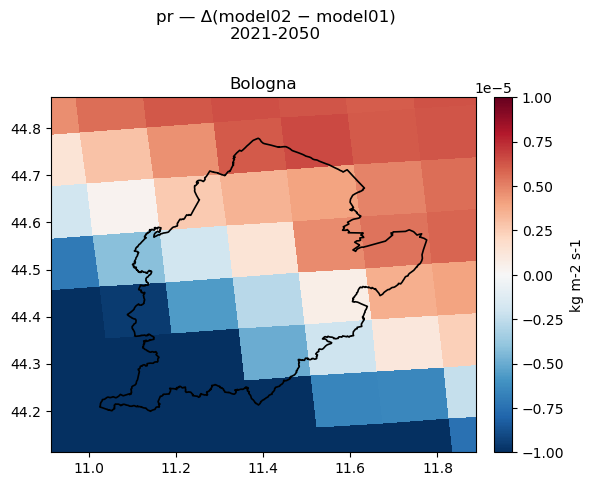


Difference map: model03 − model01
  Color scale: -2.0477496800594963e-05 to 2.0477496800594963e-05
  Saved: C:\Users\reinhvlr\OneDrive\CARMINE-T2.4\outputs\eurocordex_testing\plots\differences\pr_diff_model03_minus_model01_2021-2050.png


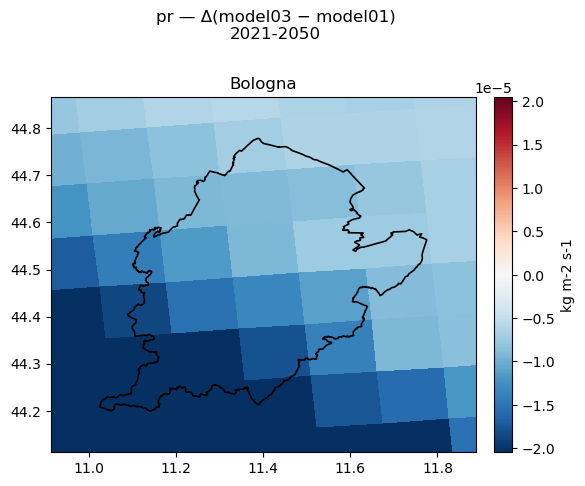

In [54]:
# =============================================================================
# DIFFERENCE MAPS — model B minus model A (period mean)
# =============================================================================

DIFF_CMAP = "RdBu_r"
ROBUST = True
PCTL = (2, 98)
CSA_TO_PLOT = "Bologna"
CSA_LIST_PLOT = [CSA_TO_PLOT]


for model_a, model_b in COMPARE_PAIRS:
    print(f"\nDifference map: {model_b} − {model_a}")

    sub_a = results_df[
        (results_df["product"] == "period_mean") &
        (results_df["period"] == PERIOD_LABEL) &
        (results_df["model_id"] == model_a)
    ]
    sub_b = results_df[
        (results_df["product"] == "period_mean") &
        (results_df["period"] == PERIOD_LABEL) &
        (results_df["model_id"] == model_b)
    ]

    if sub_a.empty or sub_b.empty:
        print("  → skipping (missing derived file)")
        continue

    path_a = Path(sub_a.iloc[0]["out_path"])
    path_b = Path(sub_b.iloc[0]["out_path"])

    ds_a = xr.open_dataset(path_a)
    ds_b = xr.open_dataset(path_b)

    try:
        da_a = ds_a[VAR_NAME].squeeze()
        da_b = ds_b[VAR_NAME].squeeze()

        diff = da_b - da_a

        lon, lat = get_lon_lat(da_a)
        if lon is None or lat is None:
            raise RuntimeError("No lon/lat coordinates found for difference map.")

        # --- compute shared symmetric color scale across CSAs ---
        all_vals = []

        #for csa in CSA_LIST:
        for csa in CSA_LIST_PLOT:    
            poly = dissolve_to_lonlat_polygon(csa)
            if poly is None:
                continue

            try:
                from shapely import contains_xy
                if lon.ndim == 1 and lat.ndim == 1:
                    xx, yy = np.meshgrid(lon, lat)
                    m = contains_xy(poly, xx, yy)
                else:
                    m = contains_xy(poly, lon, lat)
            except Exception:
                from shapely import vectorized
                if lon.ndim == 1 and lat.ndim == 1:
                    xx, yy = np.meshgrid(lon, lat)
                    m = vectorized.contains(poly, xx, yy)
                else:
                    m = vectorized.contains(poly, lon, lat)

            arr = np.asarray(diff.values, dtype="float64")
            if m.shape == arr.shape and np.any(m):
                all_vals.append(arr[m])

        all_vals = np.concatenate(all_vals)
        all_vals = all_vals[np.isfinite(all_vals)]

        if ROBUST and all_vals.size > 0:
            v = np.percentile(np.abs(all_vals), PCTL[1])
        else:
            v = float(np.nanmax(np.abs(all_vals)))

        vmin, vmax = -v, v
        print("  Color scale:", vmin, "to", vmax)

        # --- panel plot ---
        #n = len(CSA_LIST)
        n = len(CSA_LIST_PLOT)
        #ncols = 4
        #nrows = int(np.ceil(n / ncols))
        ncols = 1
        nrows = 1

        fig, ax = plt.subplots(figsize=(6, 5))
        #fig, axes = plt.subplots(
        #    nrows=nrows, ncols=ncols,
        #    figsize=(4*ncols, 3.5*nrows)
        #)
        #axes = np.array(axes).reshape(-1)

        im_last = None

        #for i, csa in enumerate(CSA_LIST):
        for i, csa in enumerate(CSA_LIST_PLOT):
            #ax = axes[i]
            poly = dissolve_to_lonlat_polygon(csa)
            if poly is None:
                ax.set_axis_off()
                ax.set_title(f"{csa} (no boundary)")
                continue

            arr = np.asarray(diff.values, dtype="float64")

            if lon.ndim == 1 and lat.ndim == 1:
                extent = [lon.min(), lon.max(), lat.min(), lat.max()]
                im = ax.imshow(
                    arr, origin="lower", extent=extent,
                    cmap=DIFF_CMAP, vmin=vmin, vmax=vmax
                )
            else:
                im = ax.pcolormesh(
                    lon, lat, arr,
                    shading="auto",
                    cmap=DIFF_CMAP, vmin=vmin, vmax=vmax
                )

            im_last = im

            # boundary + zoom
            try:
                x, y = poly.exterior.xy
                ax.plot(x, y, color="black", linewidth=1.2)
            except Exception:
                for g in getattr(poly, "geoms", []):
                    x, y = g.exterior.xy
                    ax.plot(x, y, color="black", linewidth=1.2)

            minx, miny, maxx, maxy = poly.bounds
            padx = (maxx - minx) * 0.15
            pady = (maxy - miny) * 0.15
            ax.set_xlim(minx - padx, maxx + padx)
            ax.set_ylim(miny - pady, maxy + pady)

            ax.set_title(csa)

        #for j in range(len(CSA_LIST), len(axes)):
        #for j in range(len(CSA_LIST_PLOT), len(axes)):
        #    axes[j].set_axis_off()

        #cax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
        #cbar = fig.colorbar(im_last, cax=cax)
        cbar = fig.colorbar(im_last, ax=ax, fraction=0.046, pad=0.04)
        units = diff.attrs.get("units", "")
        if units:
            cbar.set_label(units)

        fig.suptitle(
            f"{VAR_NAME} — Δ({model_b} − {model_a})\n{PANEL_PERIOD}",
            y=0.995
        )

        outdir = EUROCORDEX_TEST_OUTPUT_ROOT / "plots" / "differences"
        outdir.mkdir(parents=True, exist_ok=True)
        out_png = outdir / f"{VAR_NAME}_diff_{model_b}_minus_{model_a}_{PANEL_PERIOD}.png"
        #fig.savefig(out_png, dpi=200, bbox_inches="tight")
        #fig.subplots_adjust(right=0.9, hspace=0.35, wspace=0.25)
        fig.subplots_adjust(right=0.9, top=0.82, hspace=0.35, wspace=0.25)
        fig.savefig(out_png, dpi=200, bbox_inches="tight")
        #fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(6, 5))
        #axes = np.array([axes]) 

        print("  Saved:", out_png)
        plt.show()

    finally:
        ds_a.close()
        ds_b.close()


In [37]:
print("COMPARE_PAIRS =", COMPARE_PAIRS)

COMPARE_PAIRS = [('model01', 'model02'), ('model01', 'model03')]


In [55]:
# =============================================================================
# CSA AGGREGATION — period means → CSV
# =============================================================================

rows = []

sub = results_df[
    (results_df["product"] == "period_mean") &
    (results_df["period"] == PERIOD_LABEL) &
    (results_df["model_id"].isin(SELECT_MODELS))
].copy()

print("Aggregating CSA means for", len(sub), "derived files")

for _, r in sub.iterrows():
    model_id = r["model_id"]
    path = Path(r["out_path"])

    ds = xr.open_dataset(path)
    try:
        da = ds[VAR_NAME].squeeze()

        # remove any leftover time/year dim
        if "year" in da.dims:
            da = da.isel(year=0)
        if "time" in da.dims:
            da = da.isel(time=0)

        lon, lat = get_lon_lat(da)
        if lon is None or lat is None:
            warnings.warn(f"No lon/lat for {path.name}, skipping")
            continue

        arr = np.asarray(da.values, dtype="float64")

        for csa in CSA_LIST:
            poly = dissolve_to_lonlat_polygon(csa)
            if poly is None:
                continue

            try:
                from shapely import contains_xy
                if lon.ndim == 1 and lat.ndim == 1:
                    xx, yy = np.meshgrid(lon, lat)
                    mask = contains_xy(poly, xx, yy)
                else:
                    mask = contains_xy(poly, lon, lat)
            except Exception:
                from shapely import vectorized
                if lon.ndim == 1 and lat.ndim == 1:
                    xx, yy = np.meshgrid(lon, lat)
                    mask = vectorized.contains(poly, xx, yy)
                else:
                    mask = vectorized.contains(poly, lon, lat)

            if mask.shape != arr.shape or not np.any(mask):
                continue

            vals = arr[mask]
            vals = vals[np.isfinite(vals)]

            rows.append({
                "csa": csa,
                "model_id": model_id,
                "period": PERIOD_LABEL,
                "variable": VAR_NAME,
                "mean_value": float(np.mean(vals)),
                "n_cells": int(vals.size),
                "mean": float(np.mean(vals)),
                "median": float(np.median(vals)),
                "min": float(np.min(vals)),
                "max": float(np.max(vals)),
                "std": float(np.std(vals, ddof=0)),
            })

    finally:
        ds.close()

tables_df = pd.DataFrame(rows)
print("Rows:", len(tables_df))
display(tables_df.head())

# ---- write CSV ----
out_csv = TABLES_DIR / f"CSA_FUA_means_{VAR_NAME}_{PERIOD_LABEL}.csv"
tables_df.to_csv(out_csv, index=False)
print("Wrote:", out_csv)


Aggregating CSA means for 3 derived files
Rows: 3


,csa,model_id,period,variable,mean_value,n_cells,mean,median,min,max,std
0,Bologna,model01,2021-2050,pr,0.000035,13,0.000035,0.000033,0.000027,0.000050,0.000008
1,Bologna,model02,2021-2050,pr,0.000034,13,0.000034,0.000033,0.000031,0.000041,0.000003
2,Bologna,model03,2021-2050,pr,0.000023,13,0.000023,0.000022,0.000019,0.000029,0.000003


Wrote: C:\Users\reinhvlr\OneDrive\CARMINE-T2.4\outputs\eurocordex_testing\tables\CSA_FUA_means_pr_2021-2050.csv


In [15]:
# =============================================================================
# CSA TIME SERIES (annual values along time) → CSV (mean/median/min/max/std)
# =============================================================================
import numpy as np
import pandas as pd
import xarray as xr
import warnings

PLOT_STAT = "mean"  # just stored for later plotting; CSV will include all stats

ts_files = files_df[
    (files_df["var"] == VAR_NAME) &
    (files_df["scenario"] == SCENARIO) &
    (files_df["model_id"].isin(SELECT_MODELS))
].copy()

if ts_files.empty:
    raise ValueError("No original files found for VAR_NAME/SCENARIO/SELECT_MODELS in files_df.")

rows = []
print("Time-series source files:", len(ts_files))

for _, r in ts_files.iterrows():
    fp = Path(r["path"])
    model_id = r["model_id"]

    ds = xr.open_dataset(fp, decode_times=True)
    try:
        da = ds[VAR_NAME]

        if "time" not in da.dims:
            warnings.warn(f"No 'time' dim in {fp.name}, skipping")
            continue

        # coords (same for all timesteps)
        lon, lat = get_lon_lat(da.isel(time=0).squeeze())
        if lon is None or lat is None:
            warnings.warn(f"No lon/lat for {fp.name}, skipping")
            continue

        # precompute CSA polygons once per file
        csa_polys = {}
        for csa in CSA_LIST:
            poly = dissolve_to_lonlat_polygon(csa)
            if poly is not None:
                csa_polys[csa] = poly

        # loop timesteps (annual)
        for ti in range(da.sizes["time"]):
            tval = pd.to_datetime(da["time"].values[ti]).year
            snap = da.isel(time=ti).squeeze()
            arr = np.asarray(snap.values, dtype="float64")

            for csa, poly in csa_polys.items():
                try:
                    from shapely import contains_xy
                    if lon.ndim == 1 and lat.ndim == 1:
                        xx, yy = np.meshgrid(lon, lat)
                        mask = contains_xy(poly, xx, yy)
                    else:
                        mask = contains_xy(poly, lon, lat)
                except Exception:
                    from shapely import vectorized
                    if lon.ndim == 1 and lat.ndim == 1:
                        xx, yy = np.meshgrid(lon, lat)
                        mask = vectorized.contains(poly, xx, yy)
                    else:
                        mask = vectorized.contains(poly, lon, lat)

                if mask.shape != arr.shape or not np.any(mask):
                    continue

                vals = arr[mask]
                vals = vals[np.isfinite(vals)]
                if vals.size == 0:
                    continue

                rows.append({
                    "csa": csa,
                    "model_id": model_id,
                    "variable": VAR_NAME,
                    "scenario": SCENARIO,
                    "time": int(tval),              # string-safe
                    "n_cells": int(vals.size),
                    "mean": float(np.mean(vals)),
                    "median": float(np.median(vals)),
                    "min": float(np.min(vals)),
                    "max": float(np.max(vals)),
                    "std": float(np.std(vals, ddof=0)),
                })

    finally:
        ds.close()

ts_df = pd.DataFrame(rows)
print("Rows:", len(ts_df))
display(ts_df.head())

out_csv = TABLES_DIR / f"CSA_FUA_timeseries_{VAR_NAME}_{SCENARIO}.csv"
ts_df.to_csv(out_csv, index=False)
print("Wrote:", out_csv)


Time-series source files: 3
Rows: 390


,csa,model_id,variable,scenario,time,n_cells,mean,median,min,max,std
0,Bologna,model01,pr,rcp85,1971,13,0.000026,0.000024,0.000021,0.000037,0.000005
1,Bologna,model01,pr,rcp85,1972,13,0.000046,0.000044,0.000035,0.000065,0.000010
2,Bologna,model01,pr,rcp85,1973,13,0.000042,0.000039,0.000032,0.000059,0.000009
3,Bologna,model01,pr,rcp85,1974,13,0.000031,0.000028,0.000024,0.000044,0.000006
4,Bologna,model01,pr,rcp85,1975,13,0.000037,0.000034,0.000028,0.000054,0.000009


Wrote: C:\Users\reinhvlr\OneDrive\CARMINE-T2.4\outputs\eurocordex_testing\tables\CSA_FUA_timeseries_pr_rcp85.csv


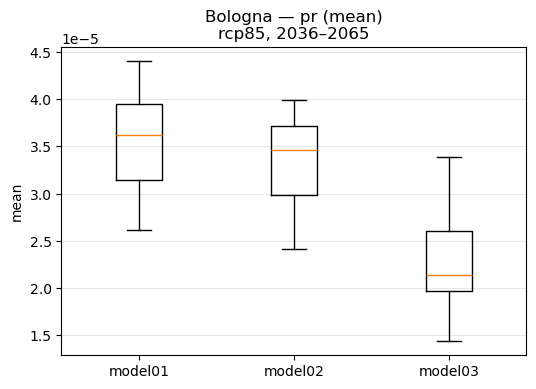

Saved: C:\Users\reinhvlr\OneDrive\CARMINE-T2.4\outputs\eurocordex_testing\plots\boxplots\boxplot_pr_rcp85_Bologna_mean_2036-2065.png


In [60]:
# =============================================================================
# BOXPLOTS — CSA time series (per model)
# =============================================================================
import pandas as pd
import matplotlib.pyplot as plt

# ---- USER CHOICES ----
BOX_CSA = "Bologna"
PLOT_STAT = "mean"   # mean, median, min, max, std
YEAR_MIN, YEAR_MAX = 2036, 2065   # set to None to ignore
YEAR_COL = "year" if "year" in ts_df.columns else "time"
ts_df[YEAR_COL] = pd.to_numeric(ts_df[YEAR_COL], errors="coerce")



assert PLOT_STAT in ["mean", "median", "min", "max", "std"]

# If not already loaded
# ts_df = pd.read_csv(TABLES_DIR / f"CSA_FUA_timeseries_{VAR_NAME}_{SCENARIO}.csv")

df = ts_df[
    (ts_df["csa"] == BOX_CSA) &
    (ts_df["model_id"].isin(SELECT_MODELS)) &
    (ts_df[YEAR_COL] >= YEAR_MIN) & (ts_df[YEAR_COL] <= YEAR_MAX)
].copy()

if df.empty:
    raise ValueError(f"No data for CSA={BOX_CSA}")

fig, ax = plt.subplots(figsize=(6, 4))

data = []
labels = []

for m in SELECT_MODELS:
    vals = df.loc[df["model_id"] == m, PLOT_STAT].dropna().values
    if len(vals) == 0:
        continue
    data.append(vals)
    labels.append(m)

ax.boxplot(data, tick_labels=labels, showfliers=False)
#ax.set_title(f"{BOX_CSA} — {VAR_NAME} ({PLOT_STAT})")
ax.set_title(
    f"{BOX_CSA} — {VAR_NAME} ({PLOT_STAT})\n"
    f"{SCENARIO}, {YEAR_MIN}–{YEAR_MAX}"
)
ax.set_ylabel(PLOT_STAT)
ax.grid(True, axis="y", alpha=0.3)

plt.show()
out_dir = PLOTS_DIR / "boxplots"
out_dir.mkdir(parents=True, exist_ok=True)

out_png = out_dir / f"boxplot_{VAR_NAME}_{SCENARIO}_{BOX_CSA}_{PLOT_STAT}_{YEAR_MIN}-{YEAR_MAX}.png"
fig.savefig(out_png, dpi=200, bbox_inches="tight")
print("Saved:", out_png)